# K-Nearest Neighbors

So far every model has learned weights from the data but KNN doesn't. It is a **nonparametric** model, which means there is no training and no parameters to learn. The model just remembers all the training data, and to classify a new point it finds the closest points to it and goes with the majority. Basically, you are what your neighbors are.

To measure "closest" we use the **Euclidean distance**, which is just the straight-line distance between two points:

$$d(p, q) = \sqrt{(p - q)^{T}(p - q)} = \sqrt{\sum_i (p_i - q_i)^2}$$

In this notebook I use KNN on the heart disease dataset to predict whether a patient has heart disease from two of their heart measurements.

## The Data

The dataset has 303 patients, each with 13 measurements (age, cholesterol, max heart rate, and so on) and a label for whether they have heart disease. I load it from the local copy at `../Datasets/heart.csv`, falling back to a public UCI mirror if the file isn't found.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split

sns.set_theme()
PURPLE, GREEN = "#5d32ca", "#82b600"

try:
    df = pd.read_csv("../Datasets/heart.csv")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Picking the Features

I use two features that separate the two groups best: **thalach** (the highest heart rate the patient reached during a stress test) and **oldpeak** (how much their ECG dipped during exercise). A diseased heart usually can't speed up as much and dips more, so these two carry a lot of the signal.

A "issue" of this dataset is the target is coded backwards, where 1 actually means healthy. So I flip it so that **1 means heart disease** and 0 means healthy.

In [4]:
X = df[["thalach", "oldpeak"]].to_numpy()
y = np.where(df["target"] == 0, 1, 0)   # flip so 1 = heart disease, 0 = healthy
print("patients:", len(y), "| with disease:", y.sum(), "| healthy:", (y == 0).sum())

patients: 303 | with disease: 138 | healthy: 165


Here are the two features, colored by whether the patient has heart disease. Disease (green) leans toward lower heart rate and higher oldpeak, but the two groups overlap a lot through the middle, which is exactly where KNN will make mistakes.

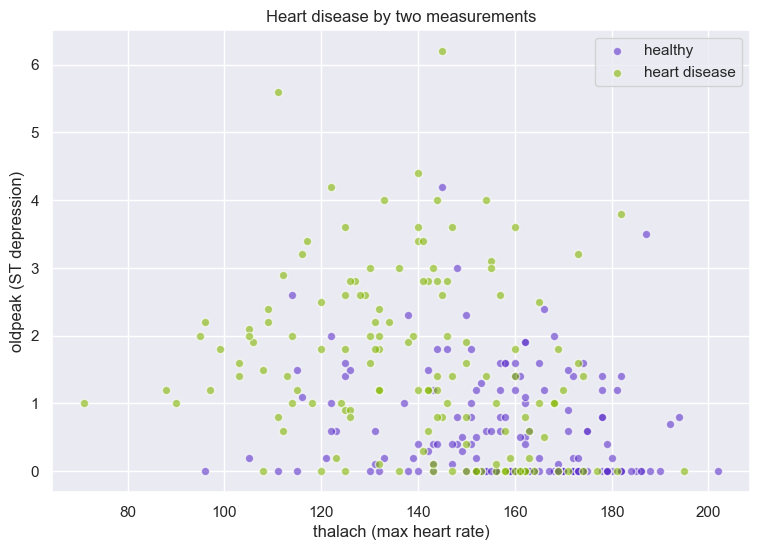

In [5]:
plt.figure(figsize=(9, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], color=PURPLE, alpha=0.6, edgecolors="white", label="healthy")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color=GREEN, alpha=0.6, edgecolors="white", label="heart disease")
plt.xlabel("thalach (max heart rate)")
plt.ylabel("oldpeak (ST depression)")
plt.title("Heart disease by two measurements")
plt.legend()
plt.show()

## Scaling and Splitting

KNN measures distance by adding up the squared difference of each feature. Max heart rate runs from about 70 to 200, while oldpeak runs from 0 to about 6. Without scaling, heart rate would completely dominate the distance and oldpeak would barely count. So I standardize both features to mean 0 and standard deviation 1 (using the training set's numbers), then split off a test set.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

# Compute mean and std on training data only, using the test set here would leak
# information about it into the scaling and inflate accuracy in a not genuine way.
mean, std = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std   # same numbers, so both sets live in the same space
print("train:", len(y_train), "| test:", len(y_test))

train: 227 | test: 76


## The Model

KNN is simple enough that the whole thing is two ideas: measure the distance from the new point to every training point, then let the **k** closest ones vote. `fit` doesn't really train anything, it just stores the data for later.

In [7]:
class KNN:
    """K-nearest neighbors classifier using Euclidean distance and majority vote."""

    def __init__(self, k=15):
        self.k = k

    def fit(self, X, y):
        # No real training. KNN just remembers the data and uses it at predict time.
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict_one(point) for point in X])

    def _predict_one(self, point):
        # Euclidean distance from this point to every training point at once.
        distances = np.sqrt(((self.X_train - point) ** 2).sum(axis=1))
        # argsort gives indices sorted by distance, so [:k] grabs the k closest.
        nearest_labels = self.y_train[np.argsort(distances)[:self.k]]
        # Return whichever label appeared most among the k neighbors.
        values, counts = np.unique(nearest_labels, return_counts=True)
        return values[counts.argmax()]

## Choosing k

How many neighbors should vote? Too few (like k=1) is noisy and follows every stray point, too many blurs everything together. I try a range of odd k values (odd avoids ties) and check the classification error on the test set.

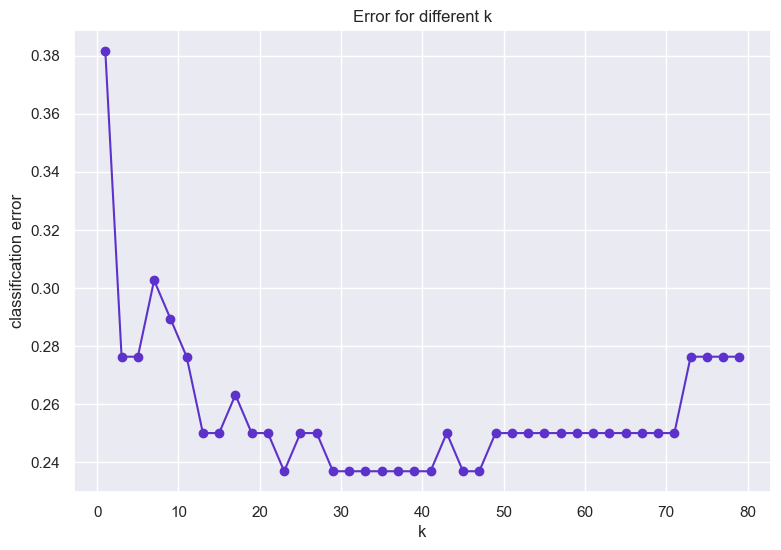

lowest error at k = 23


In [9]:
possible_k = list(range(1, 80, 2))   # odd only so there's always a majority and no ties
errors = []
for k in possible_k:
    model = KNN(k=k)
    model.fit(X_train, y_train)
    errors.append((model.predict(X_test) != y_test).mean())

# argmin gives the index of the lowest error, which maps back to the matching k
best_k = possible_k[int(np.argmin(errors))]

plt.figure(figsize=(9, 6))
plt.plot(possible_k, errors, marker="o", color=PURPLE)
plt.xlabel("k")
plt.ylabel("classification error")
plt.title("Error for different k")
plt.show()

print("lowest error at k =", best_k)

The error bottoms out around the k printed above, so I use that for the final model and check its accuracy on the test set.

In [10]:
knn = KNN(k=best_k)
knn.fit(X_train, y_train)
accuracy = (knn.predict(X_test) == y_test).mean()
print(f"Test accuracy with k={best_k}: {accuracy:.1%}")

Test accuracy with k=23: 76.3%


To see what the model actually learned, I color the whole background by what KNN would predict at each spot, then drop the test points on top. The boundary is bumpy, not a straight line, because it just follows wherever the neighbors happen to fall.

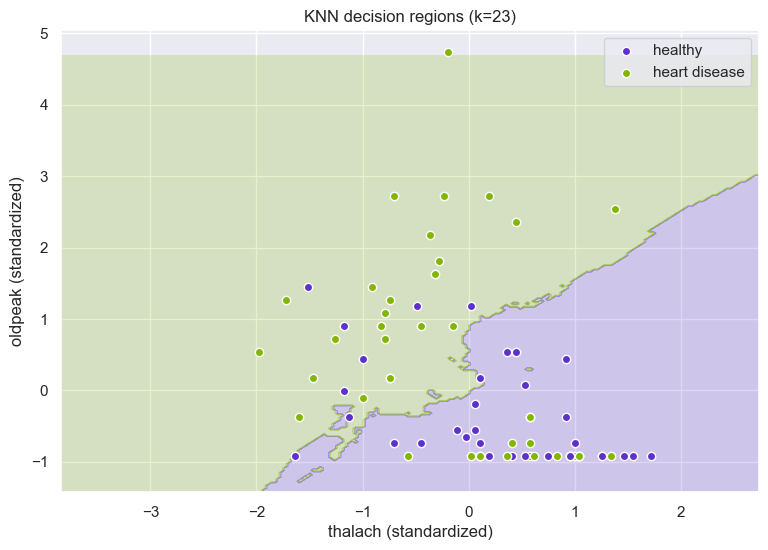

In [11]:
# Build a grid over the feature space and predict the class at every point.
xx, yy = np.meshgrid(np.linspace(X_train[:, 0].min()-0.5, X_train[:, 0].max()+0.5, 200),
                     np.linspace(X_train[:, 1].min()-0.5, X_train[:, 1].max()+0.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]   # stack into (N, 2) so predict can handle it all at once
zz = knn.predict(grid).reshape(xx.shape)   # reshape back to 2D so contourf can color it

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, zz, alpha=0.2, cmap=ListedColormap([PURPLE, GREEN]))
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], color=PURPLE, edgecolors="white", label="healthy")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], color=GREEN, edgecolors="white", label="heart disease")
plt.xlabel("thalach (standardized)")
plt.ylabel("oldpeak (standardized)")
plt.title(f"KNN decision regions (k={best_k})")
plt.legend()
plt.show()

## Using All the Features

Two features only get us so far because so many patients overlap. KNN can use all 13 measurements just as easily. The only difference is that distance is now measured in 13 dimensions instead of 2, which I can't draw but the math is the same. With everything, accuracy goes up.

In [12]:
features = ["age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"]
Xa = df[features].to_numpy()
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, y, test_size=0.25, random_state=1)
m, s = Xa_train.mean(axis=0), Xa_train.std(axis=0)
# Scaling matters even more here — 13 features with different units means distance
# would be dominated by whichever feature has the largest raw values.
Xa_train, Xa_test = (Xa_train - m) / s, (Xa_test - m) / s

# find the best k for the full feature set, the same way as before
errs = []
for k in possible_k:
    mdl = KNN(k)
    mdl.fit(Xa_train, ya_train)
    errs.append((mdl.predict(Xa_test) != ya_test).mean())
best = possible_k[int(np.argmin(errs))]

knn_all = KNN(k=best)
knn_all.fit(Xa_train, ya_train)
print(f"Test accuracy with all 13 features (k={best}): {(knn_all.predict(Xa_test) == ya_test).mean():.1%}")

Test accuracy with all 13 features (k=31): 82.9%


## Conclusion

KNN is the odd one out in this repository so far because there is no training, no weights, and nothing to minimize. It just keeps the data and lets the nearest neighbors vote. It does a decent job on the heart data, and the mistakes land right where the two groups overlap, which makes sense, because if a patient's numbers look like both groups then their neighbors are mixed too. The catch is that it has to compare against every training point for every prediction, so it gets slow on large datasets. The jump from **76.3%** (2 features) to **82.9%** (all 13) shows how much signal was hiding in the other measurements, and unlike logistic regression or a perceptron, KNN can capture nonlinear boundaries without any change to the algorithm, the neighbors just vote in higher-dimensional space.